In [1]:
import Pkg
Pkg.add(["FileIO", "ImageIO", "Colors"])

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
      Compat entries added for FileIO, ImageIO, Colors
    Updating `~/Desktop/longitudinal_dynamics/Project.toml`
  [5ae59095] + Colors v0.13.1
  [5789e2e9] + FileIO v1.20.0
  [82e4d734] + ImageIO v0.6.9
    Manifest No packages added to or removed from `~/Desktop/longitudinal_dynamics/Manifest.toml`


In [16]:
using FileIO
using ImageIO
using Colors
using Statistics
using CairoMakie
using LongitudinalTomography

const C_LIGHT_M_PER_S = 299_792_458.0

figure_path = joinpath(
    "/Users/gonza839/Desktop/longitudinal_dynamics/julia_notebooks/singleRF_grid_tomo/",
    "digitized_distributions",
    "rob2.png",
)

source_image = load(figure_path)

904×1625 Matrix{RGBA{FixedPointNumbers.N0f8}}:
 RGBA(1.0, 1.0, 1.0, 1.0)  …  RGBA(1.0, 1.0, 1.0, 1.0)
 RGBA(1.0, 1.0, 1.0, 1.0)     RGBA(1.0, 1.0, 1.0, 1.0)
 RGBA(1.0, 1.0, 1.0, 1.0)     RGBA(1.0, 1.0, 1.0, 1.0)
 RGBA(1.0, 1.0, 1.0, 1.0)     RGBA(1.0, 1.0, 1.0, 1.0)
 RGBA(1.0, 1.0, 1.0, 1.0)     RGBA(1.0, 1.0, 1.0, 1.0)
 RGBA(1.0, 1.0, 1.0, 1.0)  …  RGBA(1.0, 1.0, 1.0, 1.0)
 RGBA(1.0, 1.0, 1.0, 1.0)     RGBA(1.0, 1.0, 1.0, 1.0)
 RGBA(1.0, 1.0, 1.0, 1.0)     RGBA(1.0, 1.0, 1.0, 1.0)
 RGBA(1.0, 1.0, 1.0, 1.0)     RGBA(1.0, 1.0, 1.0, 1.0)
 RGBA(1.0, 1.0, 1.0, 1.0)     RGBA(1.0, 1.0, 1.0, 1.0)
 ⋮                         ⋱  
 RGBA(1.0, 1.0, 1.0, 1.0)  …  RGBA(1.0, 1.0, 1.0, 1.0)
 RGBA(1.0, 1.0, 1.0, 1.0)     RGBA(1.0, 1.0, 1.0, 1.0)
 RGBA(1.0, 1.0, 1.0, 1.0)     RGBA(1.0, 1.0, 1.0, 1.0)
 RGBA(1.0, 1.0, 1.0, 1.0)     RGBA(1.0, 1.0, 1.0, 1.0)
 RGBA(1.0, 1.0, 1.0, 1.0)     RGBA(1.0, 1.0, 1.0, 1.0)
 RGBA(1.0, 1.0, 1.0, 1.0)  …  RGBA(1.0, 1.0, 1.0, 1.0)
 RGBA(1.0, 1.0, 1.0, 1.0)     RGBA(1.0, 1.

In [19]:
# Julia uses row, column indexing.
# left_panel_rows  = 43:696
# left_panel_cols  = 383:996

# right_panel_rows = 43:696
# right_panel_cols = 1020:1633

# Julia uses one-based row, column indexing.

left_panel_rows = 53:706
left_panel_cols = 339:952

right_panel_rows = 53:706
right_panel_cols = 976:1589

976:1589

In [20]:
"""
Convert one plot pixel into an approximate relative density.

The conversion is based on the monotonic color progression in the supplied
figure. It suppresses grayscale pixels, including the black separatrix and
white background.
"""
function pixel_relative_density(
    pixel;
    chroma_min=0.20,
    gamma=1.0,
)
    rgb = RGB{Float64}(pixel)

    channels = (
        Float64(red(rgb)),
        Float64(green(rgb)),
        Float64(blue(rgb)),
    )

    chroma = maximum(channels) - minimum(channels)

    # Remove white background, black curves, axes, labels, and gray pixels.
    chroma < chroma_min && return 0.0

    hsv = convert(HSV, rgb)
    hue = mod(Float64(hsv.h), 360.0)
    value = maximum(channels)

    # Dark violet/blue part of the palette: use brightness to distinguish
    # the lowest density levels, whose hue is nearly constant.
    relative_density = if hue > 300.0
        1.0
    elseif hue >= 235.0
        0.02 + 0.20 * clamp(
            (value - 0.45) / 0.53,
            0.0,
            1.0,
        )
    else
        # Blue -> cyan -> green -> yellow -> orange/red.
        0.22 + 0.78 * clamp(
            (235.0 - hue) / (235.0 - 12.0),
            0.0,
            1.0,
        )
    end

    return relative_density^gamma
end


function extract_density_panel(
    image,
    rows,
    columns;
    chroma_min=0.20,
    gamma=1.0,
)
    panel = image[rows, columns]

    return map(panel) do pixel
        pixel_relative_density(
            pixel;
            chroma_min=chroma_min,
            gamma=gamma,
        )
    end
end


left_density_map = extract_density_panel(
    source_image,
    left_panel_rows,
    left_panel_cols;
    gamma=1.0,
)

right_density_map = extract_density_panel(
    source_image,
    right_panel_rows,
    right_panel_cols;
    gamma=1.0,
)

654×614 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                        ⋮              ⋱                 ⋮              
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

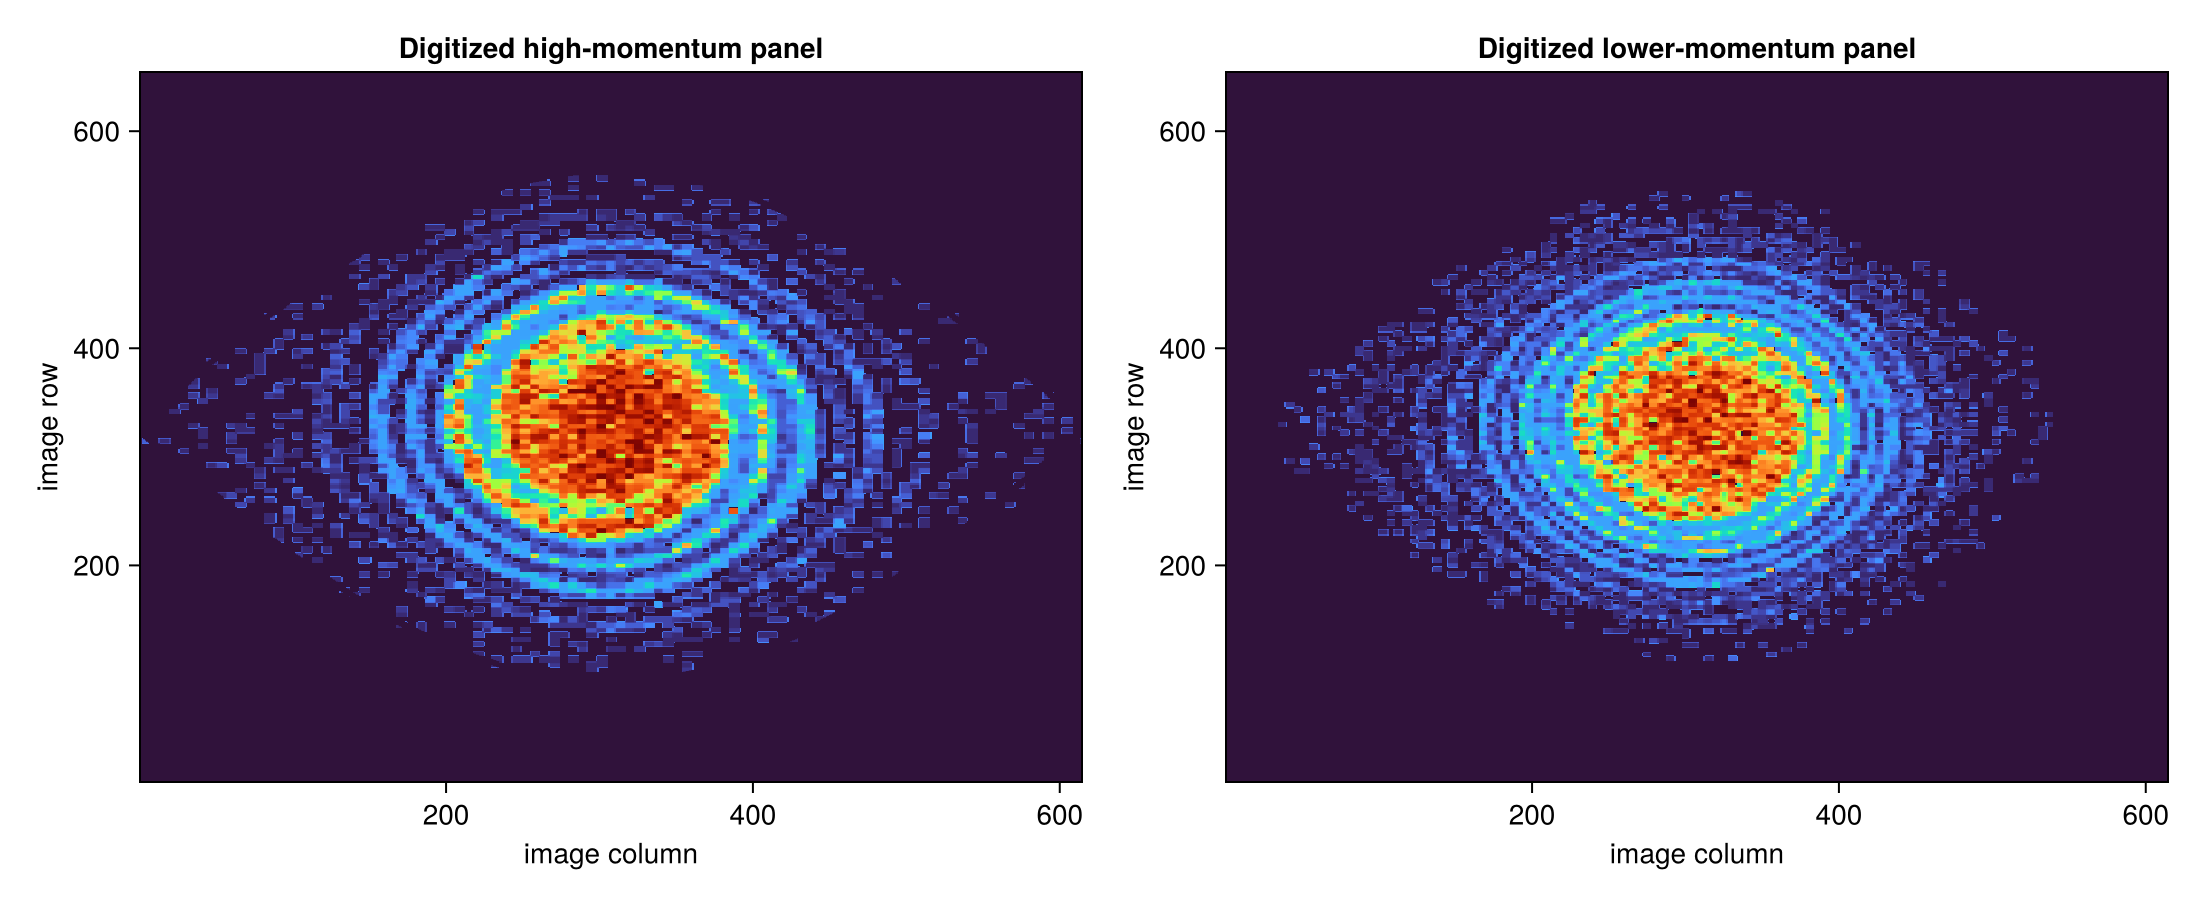

CairoMakie.Screen{IMAGE}


In [21]:
density_figure = Figure(size=(1100, 450))

left_axis = Axis(
    density_figure[1, 1];
    title="Digitized high-momentum panel",
    xlabel="image column",
    ylabel="image row",
)
heatmap!(left_axis, reverse(permutedims(left_density_map),dims=2); colormap=:turbo)

right_axis = Axis(
    density_figure[1, 2];
    title="Digitized lower-momentum panel",
    xlabel="image column",
    ylabel="image row",
)
heatmap!(right_axis, reverse(permutedims(right_density_map),dims=2); colormap=:turbo)

display(density_figure)

In [11]:
function local_physical_coordinates(
    grid,
    machine;
    flip_z=false,
    flip_delta=false,
)
    # Remove delta_t_s because the image is centered on the local
    # synchronous particle of each bucket family.
    delta_t_local =
        delta_t_from_theta(grid.theta_nodes, machine) .-
        machine.delta_t_s

    z_nodes =
        -machine.beta_s * C_LIGHT_M_PER_S .* delta_t_local

    delta_nodes = delta_p_over_p0_from_delta_E(
        delta_energy_from_P(grid.P_nodes, machine),
        machine,
    )

    flip_z && (z_nodes = -z_nodes)
    flip_delta && (delta_nodes = -delta_nodes)

    return z_nodes, delta_nodes
end


function local_physical_axes(grid, machine)
    delta_t_axis =
        delta_t_from_theta(grid.theta_axis, machine) .-
        machine.delta_t_s

    z_axis =
        -machine.beta_s * C_LIGHT_M_PER_S .* delta_t_axis

    delta_axis = delta_p_over_p0_from_delta_E(
        delta_energy_from_P(grid.P_axis, machine),
        machine,
    )

    return z_axis, delta_axis
end


"""
Map a digitized panel onto the active cells of a PhaseSpaceGrid.

The result is normalized to unit mass. Absolute bunch charge is assigned later
from BucketSpec.charge_fraction.
"""
function digitize_panel_on_grid(
    density_map,
    grid,
    machine;
    z_limits=(-2.8, 2.8),
    delta_limits=(-1.5e-3, 1.5e-3),
    cell_fraction=0.85,
    flip_z=false,
    flip_delta=false,
)
    n_rows, n_columns = size(density_map)

    z_nodes, delta_nodes = local_physical_coordinates(
        grid,
        machine;
        flip_z=flip_z,
        flip_delta=flip_delta,
    )

    z_axis, delta_axis = local_physical_axes(grid, machine)

    delta_z_cell = median(abs.(diff(z_axis)))
    delta_delta_cell = median(abs.(diff(delta_axis)))

    z_min, z_max = z_limits
    delta_min, delta_max = delta_limits

    column_radius = max(
        0,
        round(
            Int,
            0.5 * cell_fraction *
            delta_z_cell / (z_max - z_min) *
            (n_columns - 1),
        ),
    )

    row_radius = max(
        0,
        round(
            Int,
            0.5 * cell_fraction *
            delta_delta_cell / (delta_max - delta_min) *
            (n_rows - 1),
        ),
    )

    raw_weights = zeros(Float64, length(grid))

    for node_index in eachindex(grid.theta_nodes)
        z = z_nodes[node_index]
        delta = delta_nodes[node_index]

        if !(z_min <= z <= z_max &&
             delta_min <= delta <= delta_max)
            continue
        end

        column = round(
            Int,
            1 + (z - z_min) / (z_max - z_min) * (n_columns - 1),
        )

        # Image rows increase downward, whereas delta increases upward.
        row = round(
            Int,
            1 + (delta_max - delta) /
                (delta_max - delta_min) * (n_rows - 1),
        )

        first_column = clamp(column - column_radius, 1, n_columns)
        last_column  = clamp(column + column_radius, 1, n_columns)
        first_row    = clamp(row - row_radius, 1, n_rows)
        last_row     = clamp(row + row_radius, 1, n_rows)

        raw_weights[node_index] = sum(
            @view density_map[
                first_row:last_row,
                first_column:last_column,
            ]
        )
    end

    total_mass = sum(raw_weights)

    total_mass > 0 || error(
        "No colored density was mapped onto the grid. " *
        "Check the crop, physical limits, or coordinate signs.",
    )

    return (
        weights=raw_weights ./ total_mass,
        raw_weights=raw_weights,
        z_nodes=z_nodes,
        delta_nodes=delta_nodes,
    )
end

digitize_panel_on_grid